# Download Digital Elevation Model for Study Area

This notebook downloads and saves a DEM from the SRTM for the study area, using the study area boundary created in Notebook 01.

In [2]:
# import libraries

# system compatibility
import os
import pathlib
from pathlib import Path
import sys

# Data Access
import earthaccess

# Data Compatibility
import pandas as pd
import geopandas as gpd
import numpy as np
import xarray as xr

# Geographic Data
#import gdal
import rioxarray as rxr
from rasterio.enums import Resampling

# Plotting
import matplotlib
import matplotlib.pyplot as plt
import holoviews as hv
import hvplot.pandas

In [3]:
# Force Jupyter to reload external modules automatically before executing a cell
# I used Gemini to help me set up the connection to my src files

# force reimporting of src scripts
%load_ext autoreload
%autoreload 2

# Find the parent directory of this notebook (the repo root) and add it to Python's search path
repo_root = str(Path.cwd().parent)
if repo_root not in sys.path:
    sys.path.append(repo_root)

# Now Python can see the src folder
# import just specific functions
from src import dem

# once I'm using environment.yml I can get rid of the above steps

# from src
from src import dem

print('src import complete!')

src import complete!


In [ ]:
# set directories

proj_dir = os.path.join(pathlib.Path.home(),
                        'Documents',
                        'Graduate_School',
                        'EDA_Certificate', 
                        'Summer', 
                        'snow-drought-modeling')

raw_data_dir = os.path.join(proj_dir, 'data', 'raw')

cleaned_data_dir = os.path.join(proj_dir, 'data', 'cleaned')

## Step 2: Load Missouri Headwaters boundary

In [5]:
# set paths
mhw_path = Path(raw_data_dir, 'boundaries', 'mhw_gdf.parquet')
mhw_train_path = Path(cleaned_data_dir, 'boundaries', 'mhw_buff_clip_gdf.parquet')
prism_rast_path = Path(raw_data_dir, 'prism', 'full_rasters')

In [6]:
# load the mhw boundary gdf
mhw_gdf = gpd.read_parquet(mhw_path)

# and the buffered gdf
mhw_train_gdf = gpd.read_parquet(mhw_train_path)

## Step 3: Login to Earth Access Database and search for SRTM data

You will need to enter valid credentials to download the SRTM DEM.

In [7]:
# login to earthaccess

earthaccess.login()

In [8]:
# Search for SRTM data

datasets = earthaccess.search_datasets(keyword = 'SRTM DEM')
for dataset in datasets:
    print(dataset['umm']['ShortName'], dataset['umm']['EntryTitle'])

ICRAF_AfSIS_AfrHySRTM Africa Soil Information Service (AfSIS): Hydrologically Corrected/Adjusted SRTM DEM (AfrHySRTM)
NASADEM_SHHP NASADEM SRTM-only Height and Height Precision Mosaic Global 1 arc second V001
NASADEM_SIM NASADEM SRTM Image Mosaic Global 1 arc second V001
NASADEM_SSP NASADEM SRTM Subswath Global 1 arc second V001
USGS_OFR_2004_1322 Digital Shaded-Relief Map of Venezuela
C_Pools_Fluxes_CONUS_1837 CMS: Terrestrial Carbon Stocks, Emissions, and Fluxes for Conterminous US, 2001-2016
SRTMGL1 NASA Shuttle Radar Topography Mission Global 1 arc second V003
NASADEM_HGT NASADEM Merged DEM Global 1 arc second V001
AST14DEM ASTER Digital Elevation Model V004
GEDI02_B GEDI L2B Canopy Cover and Vertical Profile Metrics Data Global Footprint Level V002
SRTMGL3 NASA Shuttle Radar Topography Mission Global 3 arc second V003
GEDI01_B GEDI L1B Geolocated Waveform Data Global Footprint Level V002
SRTMGL1N NASA Shuttle Radar Topography Mission Global 1 arc second number V003
NASADEM_SC NASA

## Step 4: Download SRTM tiles

In [9]:
# set download dir and pattern

# directory
topo_dir = Path(raw_data_dir, 'topo')
os.makedirs(topo_dir, exist_ok=True)

# SRTM pattern
srtm_pattern = os.path.join(topo_dir, '*.hgt.zip')

In [10]:
# Download SRTM tiles

srtm_files = dem.download_srtm_tiles(mhw_train_gdf, topo_dir, srtm_pattern)

QUEUEING TASKS | :   0%|          | 0/12 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/12 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/12 [00:00<?, ?it/s]

## Step 5: Merge tiles

In [11]:
# Make the DA of merged tiles
mhw_elevation_da = dem.merge_srtm_tiles(srtm_pattern, mhw_train_gdf)

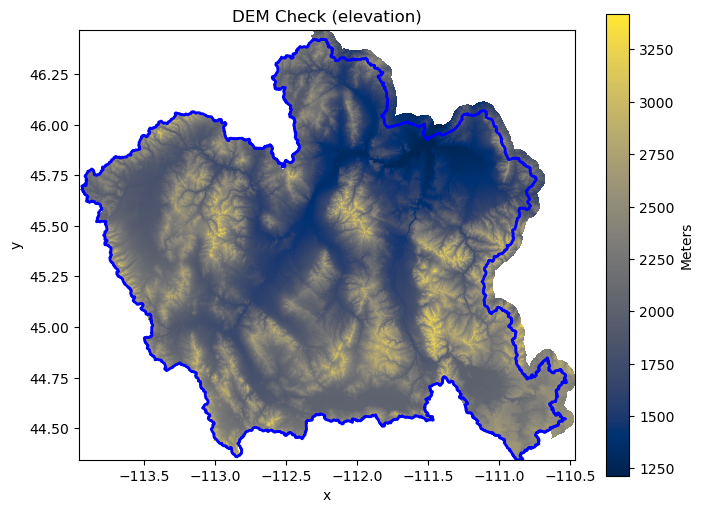

In [12]:
# visualize to check data

# set up plot
fig, ax = plt.subplots(figsize=(8,6))

# plot first timestep of prism data
mhw_elevation_da.plot(
    ax=ax, 
    cmap='cividis',
    cbar_kwargs = {'label': 'Meters'})

# overlay MHW boundary
mhw_gdf.plot(ax=ax, facecolor = 'none', edgecolor = 'blue', linewidth= 2)
plt.title('DEM Check (elevation)')
plt.show()


## Step 6: Calculate Slope and Aspect; save all three rasters

In [13]:
# calculate slope
mhw_slope_da = dem.calculate_slope(mhw_elevation_da, mhw_train_gdf)

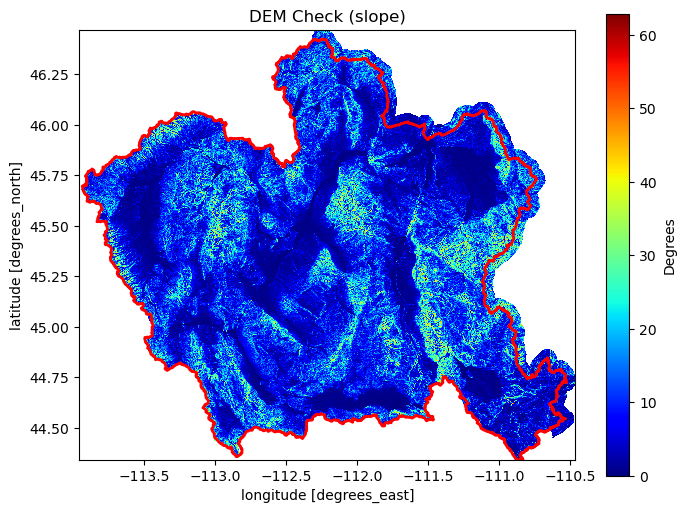

In [14]:
# visualize to check data

# set up plot
fig, ax = plt.subplots(figsize=(8,6))

# plot first timestep of prism data
mhw_slope_da.plot(
    ax=ax, 
    cmap='jet',
    cbar_kwargs = {'label': 'Degrees'})

# overlay MHW boundary
mhw_gdf.plot(ax=ax, facecolor = 'none', edgecolor = 'red', linewidth= 2)
plt.title('DEM Check (slope)')
plt.show()


In [15]:
# calculate aspect
mhw_aspect_da = dem.calculate_aspect(mhw_elevation_da, mhw_train_gdf)

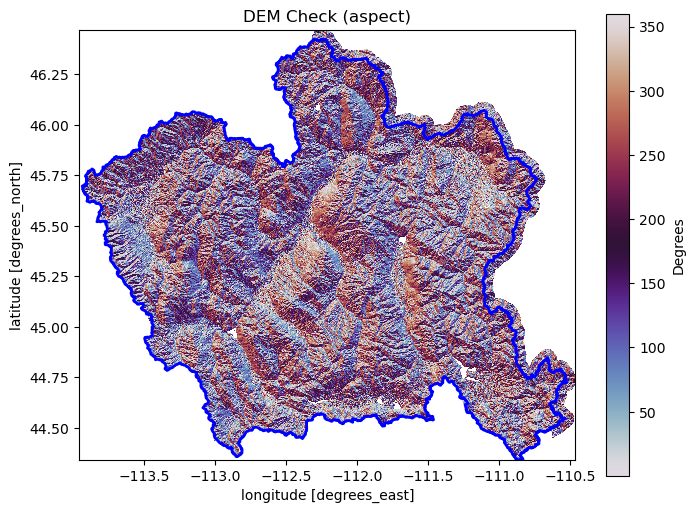

In [16]:
# visualize to check data

# set up plot
fig, ax = plt.subplots(figsize=(8,6))

# plot first timestep of prism data
mhw_aspect_da.plot(
    ax=ax, 
    cmap='twilight',
    cbar_kwargs = {'label': 'Degrees'})

# overlay MHW boundary
mhw_gdf.plot(ax=ax, facecolor = 'none', edgecolor = 'blue', linewidth= 2)
plt.title('DEM Check (aspect)')
plt.show()


In [17]:
# save to file 

# set a subfolder to hold master rasters
topo_master_dir = Path(topo_dir, 'masters')
os.makedirs(topo_master_dir, exist_ok= True)

# set paths
mhw_elevation_path = Path(topo_master_dir, 'mhw_elevation_30m.tif')
mhw_slope_path = Path(topo_master_dir, 'mhw_slope_30m.tif')
mhw_aspect_path = Path(topo_master_dir, 'mhw_aspect_30m.tif')

# clear conflicting NoData values in DAs
for da in [mhw_elevation_da, mhw_slope_da, mhw_aspect_da]:
    if '_FillValue' in da.attrs:
        del da.attrs['_FillValue']

# save
mhw_elevation_da.rio.to_raster(mhw_elevation_path)
mhw_slope_da.rio.to_raster(mhw_slope_path)
mhw_aspect_da.rio.to_raster(mhw_aspect_path)

## Step 7: Upscale to 4km resolution to match PRISM data

Because the DEM will be used alongside PRISM and MACA data, it needs to match the resolution of those grids (4km). This is fairly straightforward with elevation - obviously resolution is lost, but that's the nature of resampling. However, calculating topographic features (slope and aspect) isn't as easy. If topographic features are just calculated after resampling to 4km, subtle components of slope and aspect that have major impacts on snowmelt will be lost. Instead, I will resample all the topographic features I have (elevation, slope, and aspect) to retain information about these features when upscaling to the 4km grid. This approach is informed by [Grohmann 2015](https://doi.org/10.31223/osf.io/6xc29) and 

In [18]:
# Pull in PRISM raster for CRS and grid alignment

# set a path
prism_path = Path(cleaned_data_dir, 'prism', 'prism_mhw_1990_2020_cleaned_with_crs.nc')

# open prism dataset
prism_template = xr.open_dataset(prism_path, decode_coords='all')
prism_template = prism_template['ppt'].isel(time=0).squeeze()

In [56]:
print(prism_template.rio.crs)
print(mhw_elevation_da.rio.crs)

None
EPSG:4326


In [39]:
# resample elevation to mhw 
mhw_elev_4km_raw = mhw_elevation_da.rio.reproject_match(prism_template, resampling=Resampling.average)

# reclip to boundary area
mhw_elev_4km_da = mhw_elev_4km_raw.rio.clip(
    mhw_train_gdf.geometry,
    crs = mhw_train_gdf.crs
)

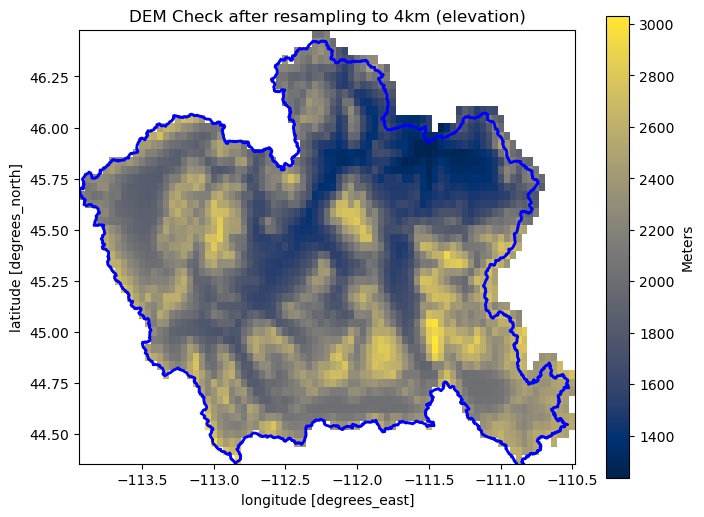

In [32]:
# visualize to check data

# set up plot
fig, ax = plt.subplots(figsize=(8,6))

# plot first timestep of prism data
mhw_elev_4km_da.plot(
    ax=ax, 
    cmap='cividis',
    cbar_kwargs = {'label': 'Meters'})

# overlay MHW boundary
mhw_gdf.plot(ax=ax, facecolor = 'none', edgecolor = 'blue', linewidth= 2)
plt.title('DEM Check after resampling to 4km (elevation)')
plt.show()

This looks great!

In [37]:
# resample slope

# set NaN value
# slope calculations use a 3x3 window - pixels on the edge will be lost due to NaNs outside being read incorrectly.
# setting NaNs tells reproject_match to ignore the NaNs in calculations 
mhw_slope_da.rio.write_nodata(np.nan, inplace=True)

# then resample
mhw_slope_4km_da_raw = mhw_slope_da.rio.reproject_match(prism_template, resampling=Resampling.average)

# then reclip to boundary
mhw_slope_4km_da = mhw_slope_4km_da_raw.rio.clip(
    mhw_train_gdf.geometry,
    crs = mhw_train_gdf.crs
)

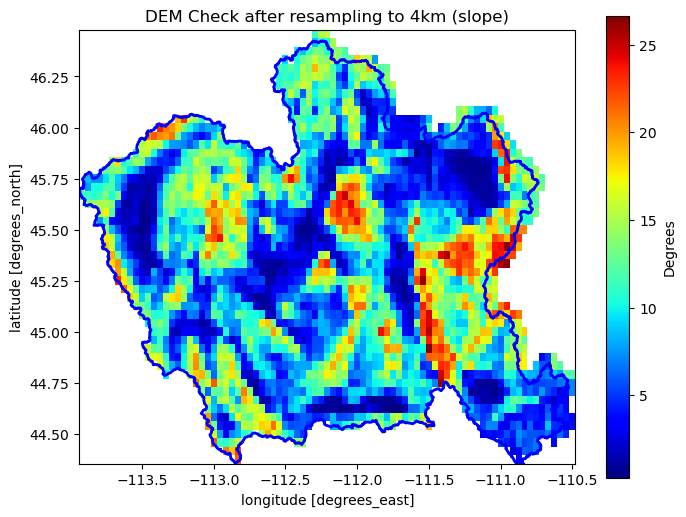

In [38]:
# visualize to check data

# set up plot
fig, ax = plt.subplots(figsize=(8,6))

# plot first timestep of prism data
mhw_slope_4km_da.plot(
    ax=ax, 
    cmap='jet',
    cbar_kwargs = {'label': 'Degrees'})

# overlay MHW boundary
mhw_gdf.plot(ax=ax, facecolor = 'none', edgecolor = 'blue', linewidth= 2)
plt.title('DEM Check after resampling to 4km (slope)')
plt.show()

This looks great!

In [ ]:
# resample aspect

# aspect can't just be resampled by averaging, because it's a measure of degrees around a circle. 
# 359 and 1 degree are actually quite similar, but averaging would treat these very differently.
# instead, I'll decompose aspect into X and Y using sine and cosine, resample, and then reconstruct 
# aspect using atan
# this methodology is informed by the work of [Grohmann 2015](https://doi.org/10.31223/osf.io/6xc29)

# get sine and cosine of aspect
# first convert to radians
mhw_aspect_rad = np.radians(mhw_aspect_da)
sin_x = np.sin(mhw_aspect_rad)
cos_y = np.cos(mhw_aspect_rad)

# resample
sin_x_rsmp = sin_x.rio.reproject_match(prism_template, Resampling=Resampling.average)
cos_y_rsmp = cos_y.rio.reproject_match(prism_template, Resampling=Resampling.average)

# reconstruct aspect
mhw_aspect_4km_rad = np.arctan2(sin_x_rsmp, cos_y_rsmp)
mhw_aspect_4km_raw_da = np.degrees(mhw_aspect_4km_rad)

# reset aspect to 0-360 degrees
# I use the equation shown in Grohmann 2015 to do this, but vectorized for xarray.Dataset
mhw_aspect_4km_da = xr.where(
    # if statement
    mhw_aspect_4km_raw_da < 90.0,
    # then
    90.0 - mhw_aspect_4km_raw_da,
    # else
    450.0 - mhw_aspect_4km_raw_da
)

# rename cos and sin to northness and eastness for ML
# ML models can't understand aspect as humans do
# 1 and 359 are nearly equivalent, but a ML model can't grasp that
mhw_aspect_4km_north_da = cos_y_rsmp
mhw_aspect_4km_east_da = sin_x_rsmp

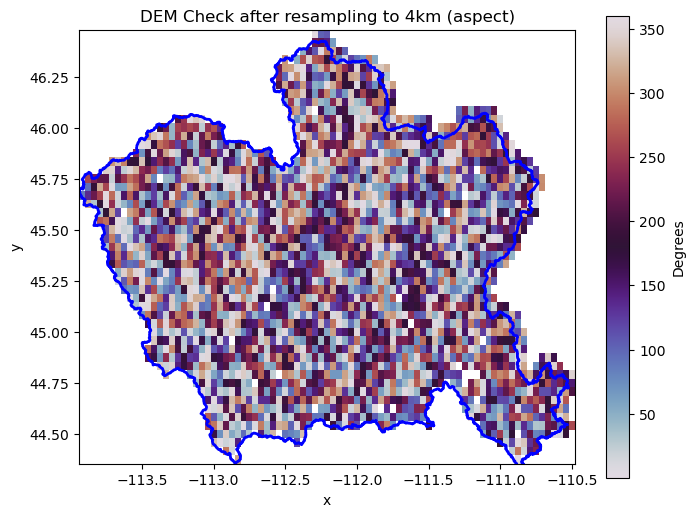

In [41]:
# visualize to check

# set up plot
fig, ax = plt.subplots(figsize=(8,6))

# plot first timestep of prism data
mhw_aspect_4km_da.plot(
    ax=ax, 
    cmap='twilight',
    cbar_kwargs = {'label': 'Degrees'})

# overlay MHW boundary
mhw_gdf.plot(ax=ax, facecolor = 'none', edgecolor = 'blue', linewidth= 2)
plt.title('DEM Check after resampling to 4km (aspect)')
plt.show()

This looks good - it seems to match the study area boundary perfectly; the scale isn't right though.

## Step 8: Save resampled DAs for future use

In [43]:
# set save dir and paths

# save dir
topo_rsmp_dir = Path(cleaned_data_dir, 'topo')
os.makedirs(topo_rsmp_dir, exist_ok=True)

# paths
elev_4km_path = Path(topo_rsmp_dir, 'mhw_elevation_4km.tif')
slope_4km_path = Path(topo_rsmp_dir, 'mhw_slope_4km.tif')
aspect_4km_path = Path(topo_rsmp_dir, 'mhw_aspect_4km.tif')
aspect_north_4km_path = Path(topo_rsmp_dir, 'mhw_northness_4km.tif')
aspect_east_4km_path = Path(topo_rsmp_dir, 'mhw_eastness_4km.tif')

In [44]:
# clear conflicting NoData values in DAs
for da in [mhw_elev_4km_da, mhw_slope_4km_da, 
           mhw_aspect_4km_da, mhw_aspect_4km_north_da, mhw_aspect_4km_east_da]:
    if '_FillValue' in da.attrs:
        del da.attrs['_FillValue']

# save rasters
mhw_elev_4km_da.rio.to_raster(elev_4km_path)
mhw_slope_4km_da.rio.to_raster(slope_4km_path)
mhw_aspect_4km_da.rio.to_raster(aspect_4km_path)
mhw_aspect_4km_north_da.rio.to_raster(aspect_north_4km_path)
mhw_aspect_4km_east_da.rio.to_raster(aspect_east_4km_path)